<a href="https://colab.research.google.com/github/I7411/THDeepLearning/blob/main/CNN_Buoi3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [3]:
import pandas as pd
import numpy as np

# Đường dẫn dữ liệu MNIST có sẵn trong Google Colab
mnist_train = "/content/sample_data/mnist_train_small.csv"
mnist_test = "/content/sample_data/mnist_test.csv"

# Đọc dữ liệu
# header=None để không làm mất dòng đầu tiên
df_train = pd.read_csv(mnist_train, header=None)
df_test = pd.read_csv(mnist_test, header=None)

print("Train dataframe:", df_train.shape)
print("Test dataframe:", df_test.shape)

# Cột 0 là nhãn, các cột còn lại là pixel
X_train = df_train.iloc[:, 1:].values
y_train = df_train.iloc[:, 0].values

X_test = df_test.iloc[:, 1:].values
y_test = df_test.iloc[:, 0].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Train dataframe: (20000, 785)
Test dataframe: (10000, 785)
X_train: (20000, 784)
y_train: (20000,)
X_test: (10000, 784)
y_test: (10000,)


In [6]:
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa pixel về [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape từ vector 784 thành ảnh 28x28x1
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))
print("First 5 labels:", y_train[:5])

X_train: (20000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
First 5 labels: [6 5 7 9 5]


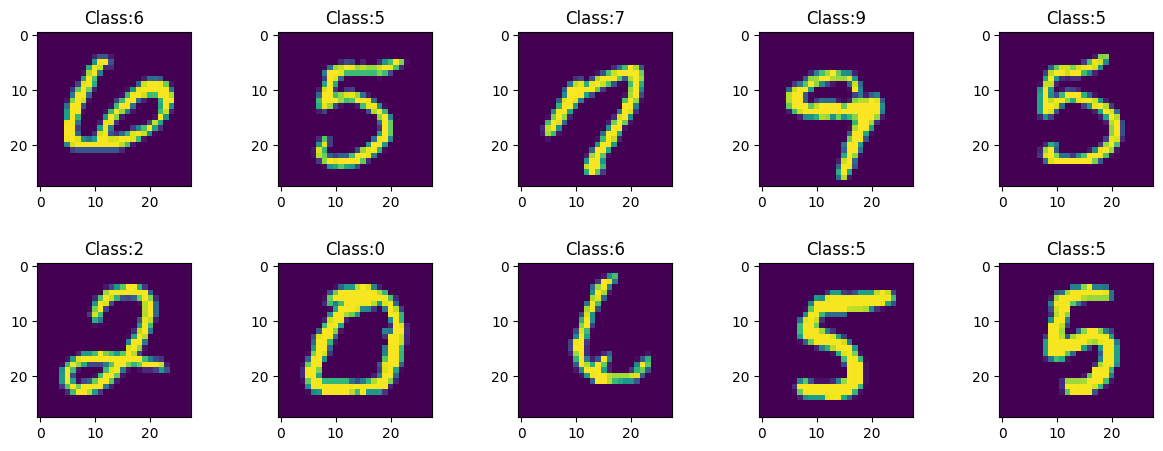

In [8]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5,figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28, 28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [9]:
y_train = keras. utils.to_categorical(y_train, num_classes)
y_test = keras.utils. to_categorical(y_test, num_classes)

In [12]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model. summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy' ])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.1093 - loss: 2.3018 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - accuracy: 0.1111 - loss: 2.3014 - val_accuracy: 0.1220 - val_loss: 2.2998
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - accuracy: 0.1111 - loss: 2.3014 - val_accuracy: 0.1220 - val_loss: 2.3000
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2996
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2997
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.1111 - loss: 2.3012 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.1111 - loss: 2.3011 - val_accuracy: 0.1220 - val_loss: 2.2995
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.1111 - loss: 2.3011 - 

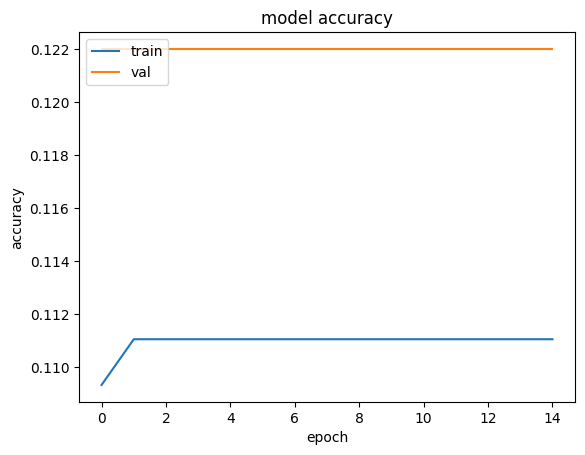

In [15]:
plt.plot(model_fit.history['accuracy' ])
plt.plot(model_fit.history['val_accuracy' ])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt. legend(['train', 'val'], loc='upper left')
plt.show()

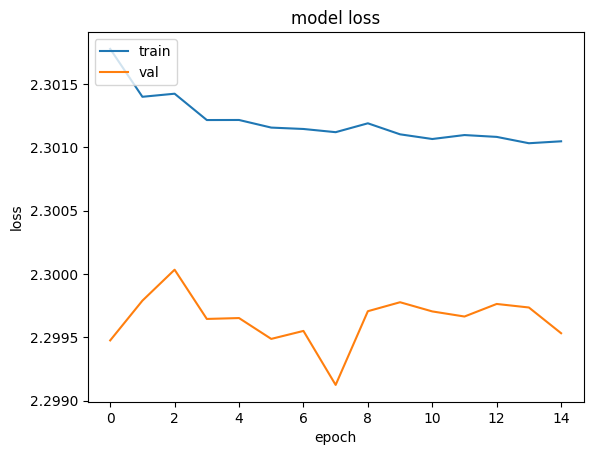

In [17]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [18]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 9ms/step - accuracy: 0.1135 - loss: 2.3013
Test loss: 2.3012826442718506
Test accuracy: 0.11349999904632568


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
[[0.09800669 0.11055191 0.0992224  0.10196631 0.09642349 0.08875446
  0.10294556 0.10511512 0.09578393 0.10123013]]
1 7


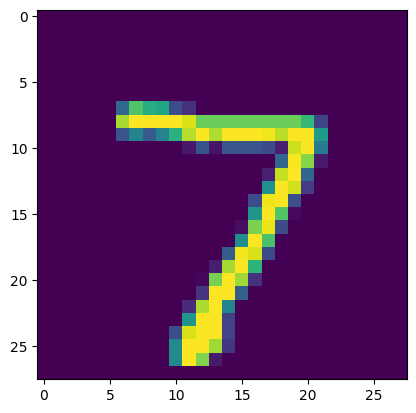

In [19]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

In [24]:
model.save("cnn.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
[[0.09999996 0.10000008 0.09999994 0.09999975 0.09999975 0.09999998
  0.10000018 0.1000001  0.10000017 0.10000011]]
6 2


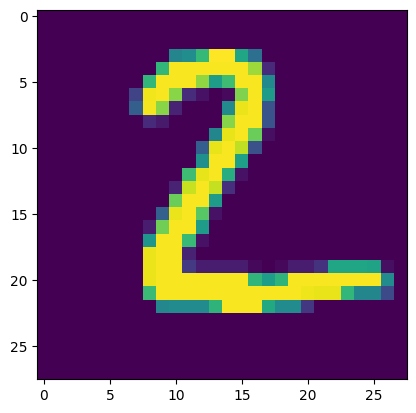

In [27]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.keras')

predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

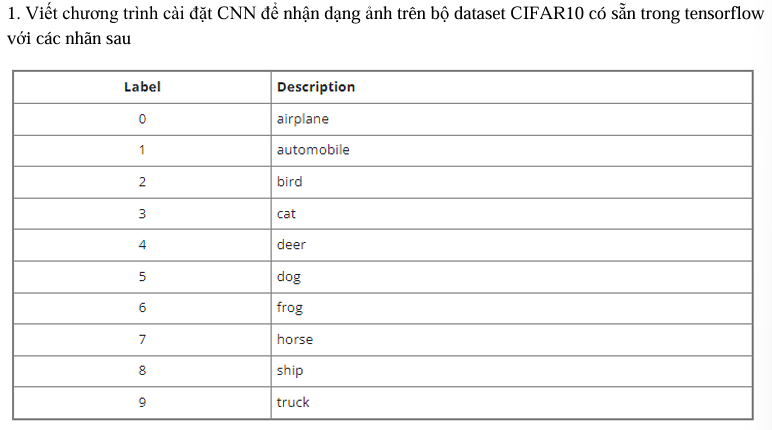

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: []


In [29]:
# Load CIFAR-10 có sẵn trong TensorFlow/Keras
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Tên các lớp
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train_full: (50000, 32, 32, 3)
y_train_full: (50000, 1)
X_test: (10000, 32, 32, 3)
y_test: (10000, 1)


In [30]:
# Chuyển label từ shape (N, 1) thành (N,)
y_train_full = y_train_full.reshape(-1)
y_test = y_test.reshape(-1)

# Chuẩn hóa pixel từ [0, 255] về [0, 1]
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Chia train thành train/validation
# 45,000 ảnh train, 5,000 ảnh validation
X_train = X_train_full[:45000]
y_train = y_train_full[:45000]

X_val = X_train_full[45000:]
y_val = y_train_full[45000:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (45000, 32, 32, 3)
y_train: (45000,)
X_val: (5000, 32, 32, 3)
y_val: (5000,)
X_test: (10000, 32, 32, 3)
y_test: (10000,)


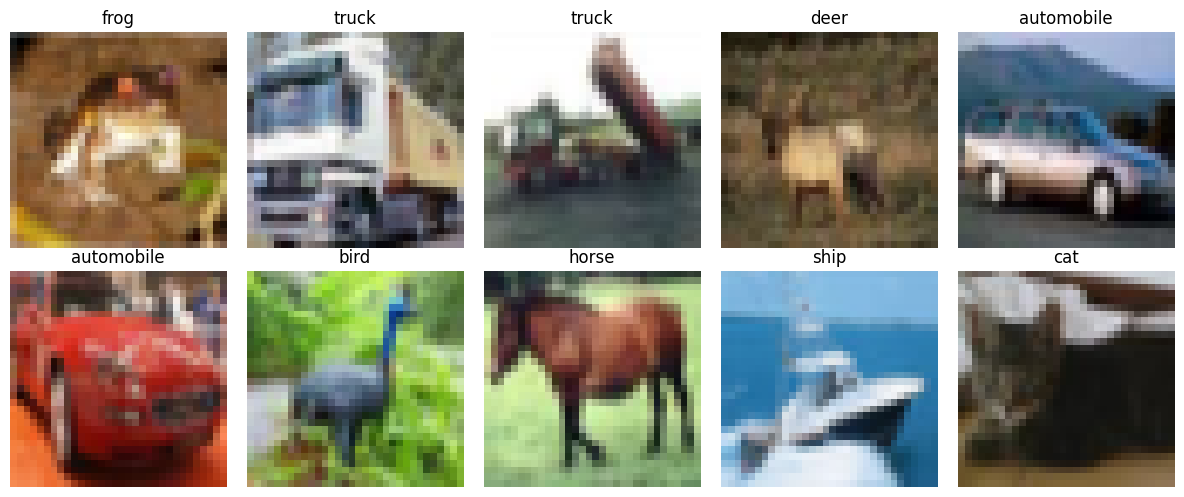

In [31]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = (
    train_ds
    .shuffle(buffer_size=10000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [33]:
num_classes = 10
input_shape = (32, 32, 3)

weight_decay = 1e-4

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name="data_augmentation")


def build_cifar10_cnn():
    inputs = layers.Input(shape=input_shape)

    # Data augmentation chỉ hoạt động khi training=True
    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.30)(x)

    # Block 3
    x = layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.35)(x)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.Dropout(0.40)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="CIFAR10_CNN")
    return model


model = build_cifar10_cnn()
model.summary()

Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [34]:
loss="sparse_categorical_crossentropy"

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
callbacks = [
    ModelCheckpoint(
        filepath="best_cifar10_cnn.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.3662 - loss: 1.7537
Epoch 1: val_accuracy improved from None to 0.41720, saving model to best_cifar10_cnn.keras

Epoch 1: finished saving model to best_cifar10_cnn.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 404s 574ms/step - accuracy: 0.4099 - loss: 1.6548 - val_accuracy: 0.4172 - val_loss: 1.8173 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.4933 - loss: 1.4536
Epoch 2: val_accuracy improved from 0.41720 to 0.52520, saving model to best_cifar10_cnn.keras

Epoch 2: finished saving model to best_cifar10_cnn.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 427s 553ms/step - accuracy: 0.5081 - loss: 1.4207 - val_accuracy: 0.5252 - val_loss: 1.3492 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.5477 - loss: 1.3370
Epoch 3: val_accuracy did not improve from 0.52520
704/704 ━━━━━━━━━━━━━━━━━━━━ 440s 551ms/step - accuracy: 0.5530 - loss: 1.3213 - val_accurac

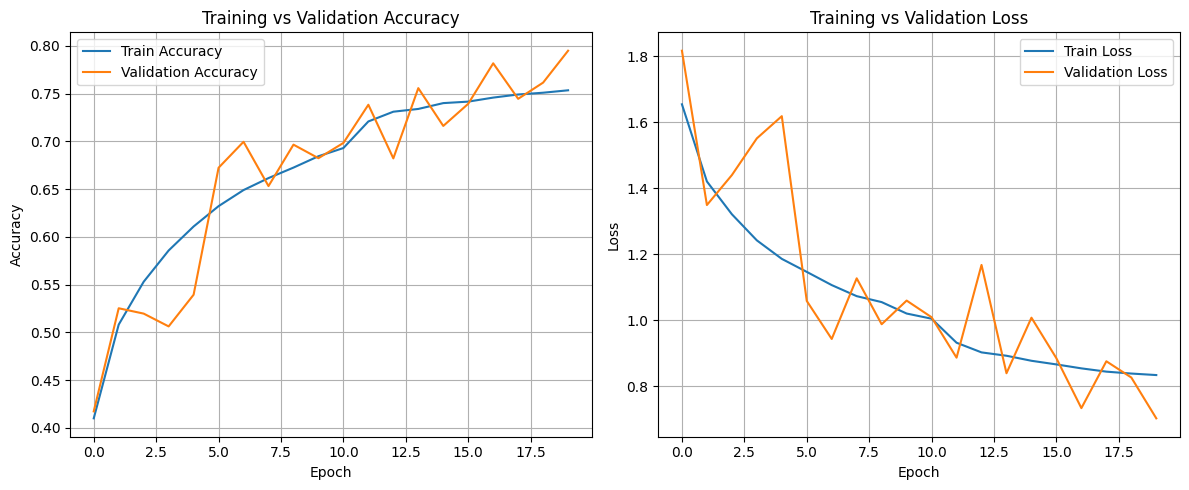

In [38]:
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.7862 - loss: 0.7384
Test Loss: 0.7383560538291931
Test Accuracy: 0.7861999869346619


In [40]:
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 166ms/step
Classification Report:
              precision    recall  f1-score   support

    airplane       0.88      0.69      0.77      1000
  automobile       0.86      0.92      0.89      1000
        bird       0.73      0.70      0.71      1000
         cat       0.68      0.65      0.66      1000
        deer       0.77      0.74      0.75      1000
         dog       0.79      0.69      0.74      1000
        frog       0.70      0.88      0.78      1000
       horse       0.84      0.83      0.84      1000
        ship       0.88      0.86      0.87      1000
       truck       0.76      0.91      0.83      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.78     10000
weighted avg       0.79      0.79      0.78     10000



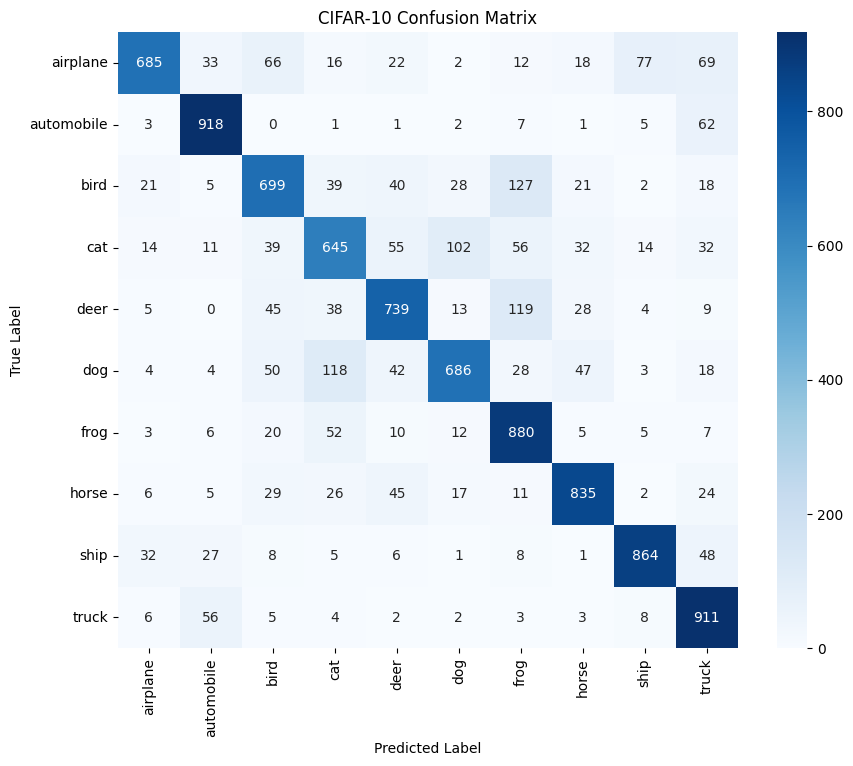

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

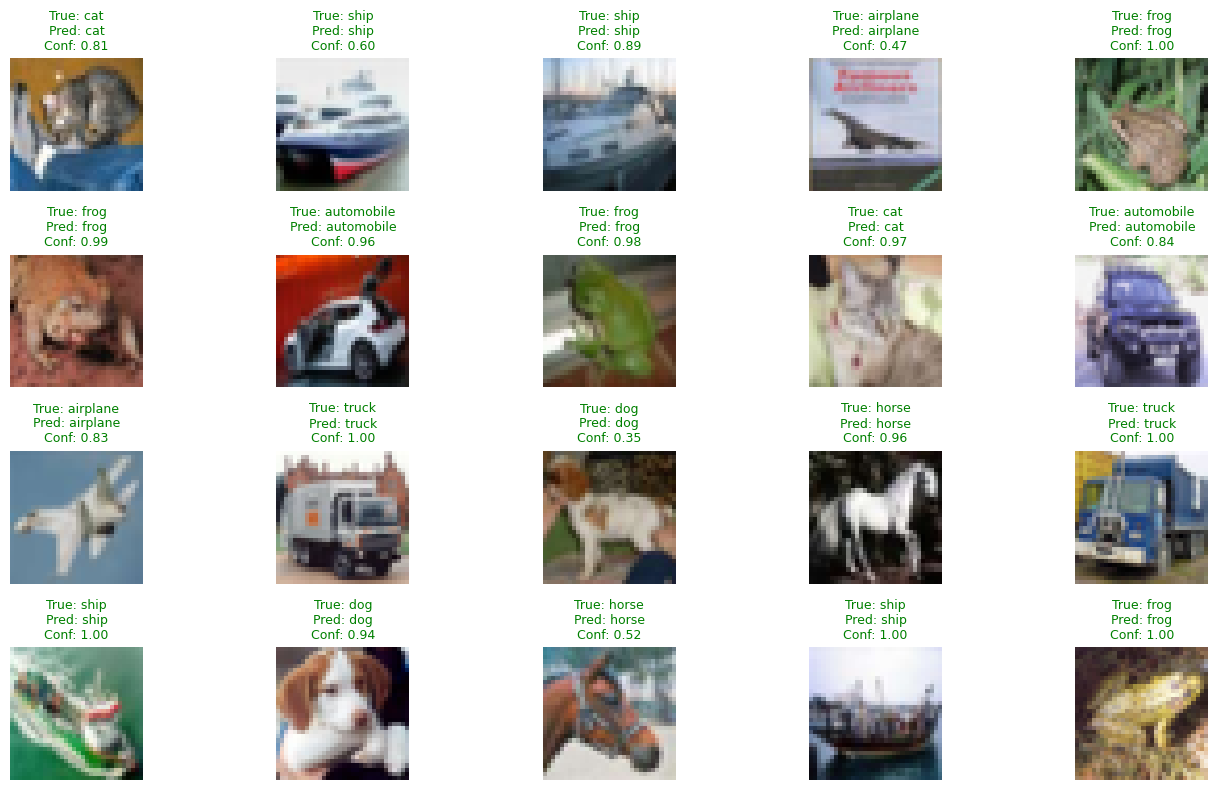

In [42]:
plt.figure(figsize=(14, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    img = X_test[i]
    true_label = y_test[i]
    pred_label = y_pred[i]
    confidence = np.max(y_pred_prob[i])

    plt.imshow(img)

    title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.2f}"

    if true_label == pred_label:
        color = "green"
    else:
        color = "red"

    plt.title(title, color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [43]:
model.save("cifar10_cnn.keras")
print("Đã lưu mô hình: cifar10_cnn.keras")

Đã lưu mô hình: cifar10_cnn.keras


In [44]:
loaded_model = tf.keras.models.load_model("cifar10_cnn.keras", compile=False)

loaded_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

loaded_model.evaluate(test_ds)

157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.7862 - loss: 0.7384


[0.7383560538291931, 0.7861999869346619]